In [34]:
import deepclean_prod as dc
from deepclean_prod.timeseries import TimeSeriesSegmentDataset

import torch
from torch.utils.data import DataLoader
import torch.optim as optim

from gwpy.timeseries import TimeSeries

import numpy as np
import matplotlib.pyplot as plt

### Training

In [25]:
franges = [
    (5, 18),
    (18, 24),
    (39, 46),
    (238, 242),
    (298, 302),
    (358, 362),
    (418, 422),
    (478, 482),
    (495, 530),
    (533, 543),
    (658, 663),
]
problem_id = 4
problem_flow = franges[problem_id][0]
problem_fhigh = franges[problem_id][1]
print(f"Target frequency band: {[problem_flow, problem_fhigh]}")

Target frequency band: [298, 302]


In [21]:
# Get data
train_kernel = 8
train_stride = 0.25
pad_mode = 'median'
train_data = TimeSeriesSegmentDataset(kernel=train_kernel, stride=train_stride, pad_mode=pad_mode)
val_data = TimeSeriesSegmentDataset(kernel=train_kernel, stride=train_stride, pad_mode=pad_mode)
channel_file = f"/home/chiajui.chou/dc_training/dc_KAGRA/chanslists/250430/chanslist_O4_{problem_flow}-{problem_fhigh}Hz.ini"
source_file = "/home/chiajui.chou/dc_training/dc_KAGRA/sources/source_O4_250430_train.ini"
fs = 4096
t0 = 1430083586
duration = 699
train_frac = 0.9
train_t0 = t0
train_duration = int(duration * train_frac)
val_t0 = train_t0 + train_duration
val_duration = duration - train_duration
train_data.load_from_source(
    channels=channel_file,
    source=source_file,
    t0=train_t0,
    duration=train_duration,
    fs=fs,
    nproc=4,
)
val_data.load_from_source(
    channels=channel_file,
    source=source_file,
    t0=val_t0,
    duration=val_duration,
    fs=fs,
    nproc=4,
)

In [22]:
print(train_data.data.shape[-1])
print(train_data.data.shape[-1]/fs)

2576384
629.0


In [23]:
# Preprocess data
filt_fl = problem_flow
filt_fh = problem_fhigh
filt_order = 8
filter_pad = 5
train_data = train_data.bandpass(
    filt_fl,
    filt_fh,
    filt_order,
    'target',
)
train_data.data = train_data.data[:, int(filter_pad*fs):-int(filter_pad*fs)]
val_data = val_data.bandpass(
    filt_fl,
    filt_fh,
    filt_order,
    'target',
)
val_data.data = val_data.data[:, int(filter_pad*fs):-int(filter_pad*fs)]
mean = train_data.mean
std = train_data.std
train_data = train_data.normalize()
val_data = val_data.normalize(mean, std)

(4, 2535424)
619.0


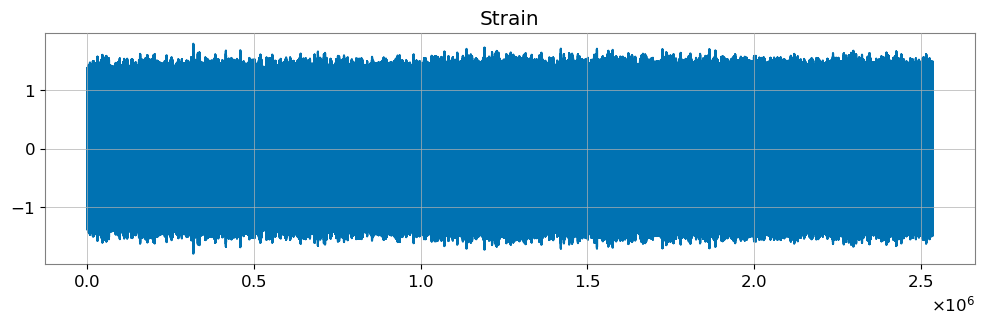

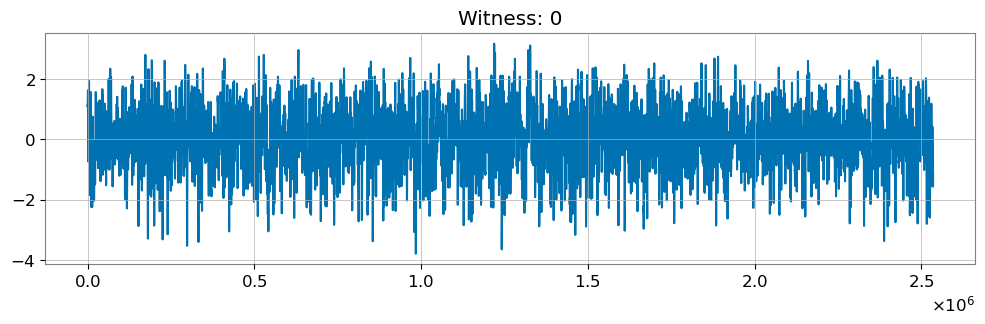

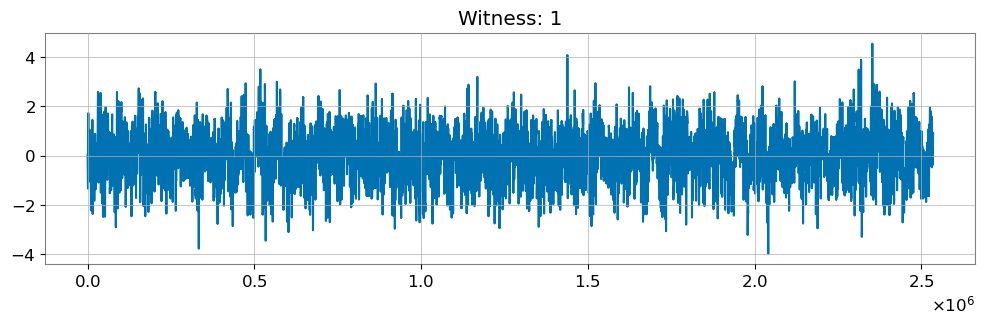

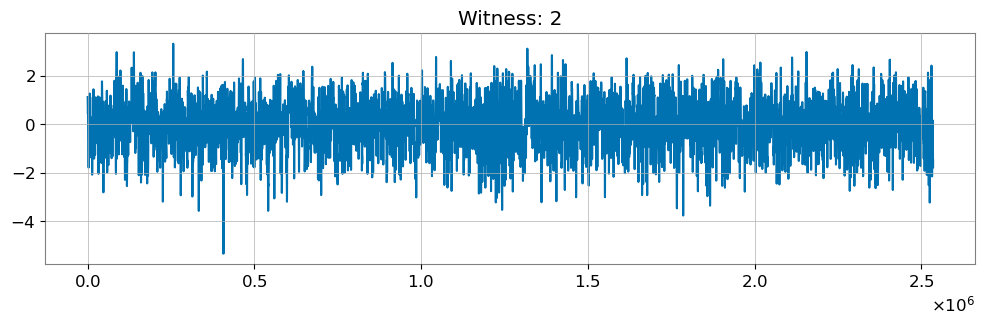

In [24]:
# print(train_data.channels)
print(train_data.data.shape)
print(train_data.data.shape[-1]/fs)
# print(train_data.target_idx)
# print(train_data.get_target())
# print(train_data.data[-1])

target_idx = train_data.target_idx
plt.figure(figsize=[12,3])
plt.title(f"Strain")
plt.plot(train_data.data[target_idx])
plt.show()
all_ids = np.arange(train_data.n_channels)
wit_ids = np.delete(all_ids, target_idx)
for id in wit_ids:
    plt.figure(figsize=[12,3])
    plt.title(f"Witness: {id}")
    plt.plot(train_data.data[id])
    plt.show()

In [26]:
# Read dataset into DataLoader
batch_size = 32
num_workers = 4
train_loader = DataLoader(
    train_data,
    batch_size,
    num_workers=num_workers,
)
val_loader = DataLoader(
    val_data,
    batch_size,
    num_workers=num_workers,
)

In [7]:
# for batch in iter(train_loader):
#     print(batch[0].shape, batch[1].shape)

In [27]:
# Creating model, loss function
device = "cuda:0"
model = dc.nn.net.DeepClean(train_data.n_channels - 1)
model = model.to(device)
fftlength = 4
overlap = None
psd_weight = 1.0
mse_weight = 0.0
coh_weight = 0.0
tf_weight = 0.0
average = 'mean'
criterion = dc.criterion.CompositePSDLoss(
    fs,
    filt_fl,
    filt_fh,
    fftlength=fftlength,
    overlap=overlap,
    psd_weight=psd_weight,
    mse_weight=mse_weight,
    coh_weight=coh_weight,
    tf_weight=tf_weight,
    reduction='sum',
    device=device,
    average=average,
)

# Defining optimizer and learning rate scheduler
lr = 1e-3
weight_decay = 1e-5
optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, 10, 0.1)

In [28]:
# Training
num_batches = len(train_loader)
max_epochs = 20

for epoch in range(max_epochs):
    print(f"Epoch: {epoch}")
    train_loss = 0.
    model.train()
    for i_batch, (witness, target) in enumerate(train_loader):
        optimizer.zero_grad()
        # Move batch to GPU if available
        witness = witness.to(device)
        target = target.to(device)
        # Forward pass
        pred = model(witness)
        # Calculate loss function and backward pass
        loss = criterion(pred, target, witness)
        loss.backward()
        # Clip gradients after backward but before step
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )
        # Gradient descent
        optimizer.step()
        #Updating training loss
        if criterion.reduction == 'mean':
            train_loss += loss.item() * len(witness)
        else:
            train_loss += loss.item()

    # Evaluating performance on validation set if given
    val_loss = 0
    if val_loader is not None:
        model.eval()
        with torch.no_grad():
            for i_batch, (witness, target) in enumerate(val_loader):
                # Move batch to GPU if available
                witness = witness.to(device)
                target = target.to(device)
                # Forward pass
                pred = model(witness)
                # Calculate and update validation loss
                loss = criterion(pred, target, witness)
                if criterion.reduction == 'mean':
                    val_loss += loss.item() * len(witness)
                else:
                    val_loss += loss.item()

    # Compute average loss over all samples
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset) if val_loader is not None else 1.0 # avoid divided by 0.

    # Update LR with scheduler at the end of each epoch
    if lr_scheduler is not None:
        lr_scheduler.step()

    # Update metric
    print(f"Train loss: {train_loss}, Validation loss: {val_loss}")


Epoch: 0
Train loss: 0.9375386119132637, Validation loss: 0.9376160699214662
Epoch: 1
Train loss: 0.9374156834889044, Validation loss: 0.9376287004023648
Epoch: 2
Train loss: 0.9374971920239658, Validation loss: 0.9373933253676127
Epoch: 3
Train loss: 0.9375448316640406, Validation loss: 0.9376201538377972
Epoch: 4
Train loss: 0.9374177039522822, Validation loss: 0.9378415021029386
Epoch: 5
Train loss: 0.9374649843555286, Validation loss: 0.9376174570841082
Epoch: 6
Train loss: 0.9373933495675616, Validation loss: 0.9372322593579452
Epoch: 7
Train loss: 0.9374707691996131, Validation loss: 0.9386277084715628
Epoch: 8
Train loss: 0.9376224158975488, Validation loss: 0.9375475011944201
Epoch: 9
Train loss: 0.9375569396223759, Validation loss: 0.9375740352429842
Epoch: 10
Train loss: 0.937561894048211, Validation loss: 0.9377194500425786
Epoch: 11
Train loss: 0.9375938992802595, Validation loss: 0.9375438142621346
Epoch: 12
Train loss: 0.9375622747378359, Validation loss: 0.93754391008586

### Cleaning

In [31]:
# Get data
clean_kernel = 8
clean_stride = 4
pad_mode = 'median'
data = TimeSeriesSegmentDataset(kernel=train_kernel, stride=train_stride, pad_mode=pad_mode)
channel_file = "/home/chiajui.chou/dc_training/dc_KAGRA/chanslists/250430/chanslist_O4_238-242Hz.ini"
source_file = "/home/chiajui.chou/dc_training/dc_KAGRA/sources/source_O4_250430_clean.ini"
fs = 4096
clean_t0 = 1430082886
clean_duration = 349
data.load_from_source(
    channels=channel_file,
    source=source_file,
    t0=clean_t0,
    duration=clean_duration,
    fs=fs,
    nproc=4,
)

# Preprocess data
preprocessed = data.bandpass(
    fl=filt_fl,
    fh=filt_fh,
    order=filt_order,
    channels='target',
)
preprocessed.normalize(mean, std)

# Load preprocessed data into dataloader
window = 'hanning'
data_loader = DataLoader(
    preprocessed,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
)

# Data cleaning
model.eval()
with torch.no_grad():
    target = data.get_target()
    pred_batches = dc.nn.utils.evaluate(
        data_loader,
        model,
        device=device,
    )

noverlap = int((preprocessed.kernel - preprocessed.stride) * preprocessed.fs)
pred = dc.dc_signal.overlap_add(
    pred_batches,
    noverlap,
    window=window,
)
pred *= std[preprocessed.target_idx].ravel()
pred += mean[preprocessed.target_idx].ravel()
pred = dc.dc_signal.filter_add(
    data=pred,
    fs=preprocessed.fs,
    flow=filt_fl,
    fhigh=filt_fh,
    order=filt_order
)
pred = pred[:target.size]

# Subtract noise prediction from raw data
clean = target - pred

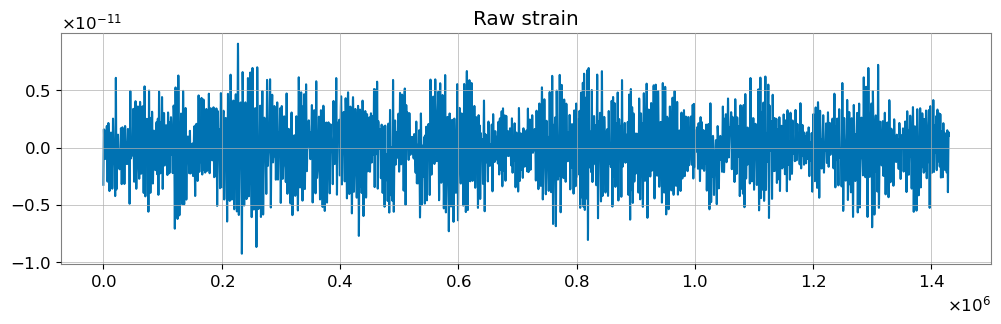

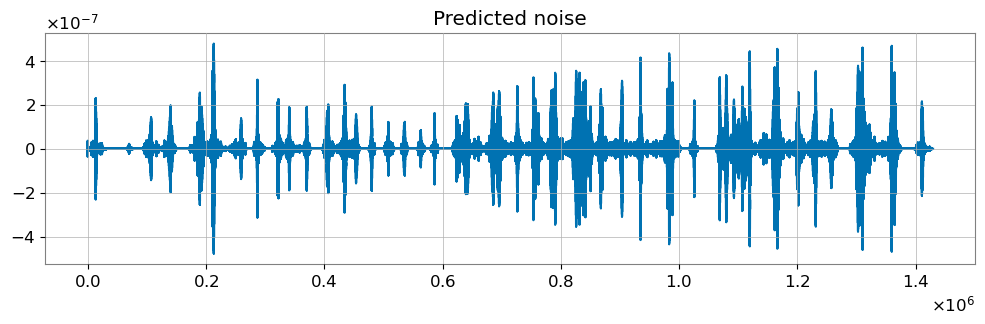

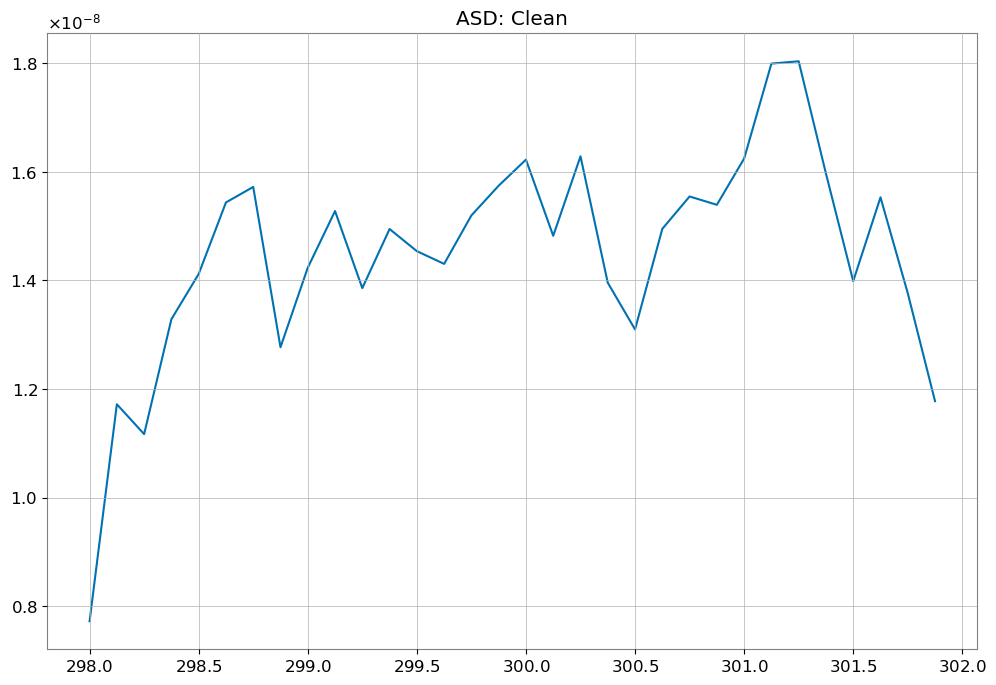

In [39]:
plt.figure(figsize=[12,3])
plt.title("Raw strain")
plt.plot(target)
plt.show()

plt.figure(figsize=[12,3])
plt.title("Predicted noise")
plt.plot(pred)
plt.show()

target_ts = TimeSeries(
    target,
    t0=clean_t0,
    sample_rate=fs,
    channel="preprocessed.channels[preprocessed.target_idx]",
)
pred_ts = TimeSeries(
    pred,
    t0=clean_t0,
    sample_rate=fs,
    channel="preprocessed.channels[preprocessed.target_idx]",
)
clean_ts = TimeSeries(
    clean,
    t0=clean_t0,
    sample_rate=fs,
    channel=f"{preprocessed.channels[preprocessed.target_idx]}_DC",
)

clean_asd = clean_ts.asd(
    fftlength=8,
    overlap=4,
    method='median',
)
fid_st, fid_ed = int(filt_fl/clean_asd.df.value), int(filt_fh/clean_asd.df.value)
plt.figure(figsize=[12,8])
plt.title("ASD: Clean")
plt.plot(clean_asd.frequencies[fid_st:fid_ed], clean_asd[fid_st:fid_ed])
plt.show()